# Example 14: Optical Navigation from Synthetic Lunar Horizon Images

This tutorial builds a compact optical-navigation pipeline for a spacecraft in lunar orbit. It combines LuPNT orbit propagation, synthetic image generation, image processing, geometric measurement formation, and an EKF.

The simplified measurement is the apparent lunar disk. For a spherical Moon with radius $R_M$, the fitted image radius gives angular radius

$$
\alpha = \tan^{-1}\left(\frac{r_{px}}{f_{px}}\right), \qquad
\rho = \frac{R_M}{\sin\alpha},
$$

and the fitted disk center gives the bearing to the Moon center. With known camera attitude, each image becomes an approximate Moon-centered position measurement.

The example intentionally keeps the shape model spherical and the attitude known so the mathematical structure is visible before adding real-world complications such as terrain relief, phase, distortion, or attitude uncertainty.

In [1]:
import json
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.patches import Circle

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        REPO_ROOT = _b
        break
else:
    REPO_ROOT = Path.cwd()

try:
    import pylupnt as pnt
except Exception as exc:
    raise RuntimeError(
        "Example 14 uses LuPNT constants and planetary ephemerides. Run "
        "`pixi run build-py` or `pixi run install-kernel` before executing the notebook."
    ) from exc

GM_MOON = float(pnt.GM_MOON)  # [m^3/s^2]
R_MOON = float(pnt.R_MOON)  # [m]
PNT_SOURCE = "pylupnt"

OUT_DIR = REPO_ROOT / "output/python_examples/ex14_opnav_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.grid": True})
rng = np.random.default_rng(42)
print(f"Using lunar constants from {PNT_SOURCE}")
print(f"Python       : {sys.version.split()[0]}")
print(f"Output directory: {OUT_DIR}")

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.00][PyLuPNT] Initializing


Using lunar constants from pylupnt
Python       : 3.11.15
Output directory: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output


## 1. Orbit and camera setup

The truth trajectory is a moderately high circular lunar orbit. A high orbit keeps the full lunar disk inside a modest field of view, so a simple circle fit can recover the limb from each image. The camera is nadir-pointed: its optical axis tracks the Moon center, and its attitude is assumed known by the filter.


In [2]:
def rot1(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def rot3(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])


def circular_state(radius_m, inclination_rad, raan_rad, true_anomaly_rad):
    r_pf = radius_m * np.array(
        [np.cos(true_anomaly_rad), np.sin(true_anomaly_rad), 0.0]
    )
    v_pf = np.sqrt(GM_MOON / radius_m) * np.array(
        [-np.sin(true_anomaly_rad), np.cos(true_anomaly_rad), 0.0]
    )
    q_p2i = rot3(raan_rad) @ rot1(inclination_rad)
    return np.hstack((q_p2i @ r_pf, q_p2i @ v_pf))


def look_at_moon_dcm_ci_to_cam(r_sc_ci):
    """Rows are inertial unit vectors of the camera x, y, z axes; camera +z points to Moon center."""
    z_cam_i = -r_sc_ci / np.linalg.norm(r_sc_ci)
    ref_i = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(ref_i, z_cam_i)) > 0.92:
        ref_i = np.array([0.0, 1.0, 0.0])
    x_cam_i = np.cross(ref_i, z_cam_i)
    x_cam_i /= np.linalg.norm(x_cam_i)
    y_cam_i = np.cross(z_cam_i, x_cam_i)
    return np.vstack((x_cam_i, y_cam_i, z_cam_i))


# Truth orbit.
altitude_m = 2600.0e3
orbit_radius_m = R_MOON + altitude_m
inclination = np.deg2rad(55.0)
raan = np.deg2rad(35.0)
period_s = 2.0 * np.pi * np.sqrt(orbit_radius_m**3 / GM_MOON)
mean_motion = np.sqrt(GM_MOON / orbit_radius_m**3)

n_images = 18
observation_arc_fraction = 0.36
times_s = np.linspace(0.0, observation_arc_fraction * period_s, n_images)

epoch_utc = "2025-01-01T00:00:00"
t0_utc = pnt.gregorian_to_time(epoch_utc)
t0_tdb = pnt.convert_time(t0_utc, pnt.Time.UTC, pnt.Time.TDB)
times_tdb = t0_tdb + times_s

# Choose the initial true anomaly so the midpoint image is taken from the Moon's sunward side.
# This keeps the optical navigation frames bright while preserving the inclined lunar orbit.
q_p2i = rot3(raan) @ rot1(inclination)
t_mid_tdb = float(t0_tdb + 0.5 * times_s[-1])
sun_mid_ci = np.asarray(
    pnt.get_body_pos(t_mid_tdb, pnt.BodyId.MOON, pnt.BodyId.SUN, pnt.Frame.MOON_CI),
    dtype=float,
).reshape(3)
sun_mid_ci /= np.linalg.norm(sun_mid_ci)
sun_mid_pf = q_p2i.T @ sun_mid_ci
bright_mid_true_anomaly = np.arctan2(sun_mid_pf[1], sun_mid_pf[0])
true_anomaly0 = bright_mid_true_anomaly - mean_motion * 0.5 * times_s[-1]
truth = np.array(
    [
        circular_state(
            orbit_radius_m, inclination, raan, true_anomaly0 + mean_motion * t
        )
        for t in times_s
    ]
)

# Use LuPNT's planetary ephemeris routine for the Moon-to-Sun vector in MOON_CI.
sun_moon_ci_m = np.array(
    [
        np.asarray(
            pnt.get_body_pos(
                float(t), pnt.BodyId.MOON, pnt.BodyId.SUN, pnt.Frame.MOON_CI
            ),
            dtype=float,
        ).reshape(3)
        for t in times_tdb
    ]
)
sun_ci = sun_moon_ci_m / np.linalg.norm(sun_moon_ci_m, axis=1, keepdims=True)
moon_to_sc_ci = truth[:, :3] / np.linalg.norm(truth[:, :3], axis=1, keepdims=True)
phase_angle_deg = np.rad2deg(
    np.arccos(np.clip(np.sum(moon_to_sc_ci * sun_ci, axis=1), -1.0, 1.0))
)

# Pinhole camera model.
cam = {
    "width": 256,
    "height": 256,
    "fov_deg": 50.0,
}
cam["cx"] = (cam["width"] - 1) / 2.0
cam["cy"] = (cam["height"] - 1) / 2.0
cam["f_px"] = 0.5 * cam["width"] / np.tan(np.deg2rad(cam["fov_deg"]) / 2.0)

att_ci_to_cam = np.array([look_at_moon_dcm_ci_to_cam(rv[:3]) for rv in truth])

print(f"Orbit radius : {orbit_radius_m / 1e3:.1f} km")
print(f"Altitude     : {altitude_m / 1e3:.1f} km")
print(f"Period       : {period_s / 3600.0:.2f} h")
print(f"Image cadence: {np.median(np.diff(times_s)) / 60.0:.1f} min")
print(f"Observation arc: {observation_arc_fraction:.2f} orbit")
print(
    f"Camera       : {cam['width']} x {cam['height']} px, {cam['fov_deg']:.1f} deg FOV"
)
print(f"Epoch UTC    : {epoch_utc}")
print(f"Moon-Sun dist: {np.linalg.norm(sun_moon_ci_m[0]) / 1e9:.2f} million km")
print(f"Phase angles : {phase_angle_deg.min():.1f}-{phase_angle_deg.max():.1f} deg")

Orbit radius : 4337.4 km


Altitude     : 2600.0 km
Period       : 7.12 h
Image cadence: 9.0 min
Observation arc: 0.36 orbit
Camera       : 256 x 256 px, 50.0 deg FOV
Epoch UTC    : 2025-01-01T00:00:00
Moon-Sun dist: 146.74 million km
Phase angles : 28.1-67.8 deg


## 2. Render synthetic Moon images

The `render_moon_blender` function creates a textured Moon sphere, a camera at the origin, a physically rough lunar material, directional sunlight, weak camera-side fill for night-side limb visibility, and a sparse star background. It downloads the small NASA SVS CGI Moon Kit preview maps on first run and caches them under the notebook output directory.

Texture sources: NASA Scientific Visualization Studio's [CGI Moon Kit](https://svs.gsfc.nasa.gov/4720), using the 2025 LROC WAC color map (`lroc_color_2k.jpg`) for surface color and the LOLA-derived preview displacement map (`ldem_3_8bit.jpg`) as a visual bump map. Blender's camera looks along local `-Z`, so the helper maps this notebook's camera `+Z` convention into Blender coordinates internally.

This example requires Blender's Python module (`bpy`). In this repository, run `pixi install` and use the LuPNT pixi kernel with `bpy==4.5.11`.

In [3]:
import urllib.request

try:
    import bpy
    from mathutils import Vector
except Exception as exc:
    raise RuntimeError(
        "Example 14 renders images with Blender only. Run `pixi install`, select the "
        "LuPNT pixi kernel, and confirm `bpy==4.5.11` is available."
    ) from exc

NASA_MOON_KIT_URL = "https://svs.gsfc.nasa.gov/4720"
TEXTURE_DIR = OUT_DIR / "nasa_cgi_moon_kit"
TEXTURE_DIR.mkdir(parents=True, exist_ok=True)
NASA_TEXTURES = {
    "color": (
        "lroc_color_2k.jpg",
        "https://svs.gsfc.nasa.gov/vis/a000000/a004700/a004720/lroc_color_2k.jpg",
    ),
    "height": (
        "ldem_3_8bit.jpg",
        "https://svs.gsfc.nasa.gov/vis/a000000/a004700/a004720/ldem_3_8bit.jpg",
    ),
}


def download_nasa_texture(kind):
    filename, url = NASA_TEXTURES[kind]
    path = TEXTURE_DIR / filename
    if not path.exists():
        print(f"Downloading NASA CGI Moon Kit {kind} map: {filename}")
        urllib.request.urlretrieve(url, path)
    return path


LUNAR_COLOR_MAP = download_nasa_texture("color")
LUNAR_HEIGHT_MAP = download_nasa_texture("height")


def blender_vec_from_cam(v_cam):
    return np.array([v_cam[0], v_cam[1], -v_cam[2]], dtype=float)


def point_sun_from_direction(light, sun_cam):
    sun_bl = blender_vec_from_cam(sun_cam)
    sun_bl /= np.linalg.norm(sun_bl)
    ray_dir = Vector((-sun_bl[0], -sun_bl[1], -sun_bl[2]))
    light.rotation_euler = ray_dir.to_track_quat("-Z", "Y").to_euler()


def make_lunar_material(color_map, height_map):
    mat = bpy.data.materials.new("NASA_LROC_LOLA_lunar_surface")
    mat.use_nodes = True
    nodes = mat.node_tree.nodes
    links = mat.node_tree.links
    bsdf = nodes.get("Principled BSDF")

    color_tex = nodes.new("ShaderNodeTexImage")
    color_tex.name = "NASA LROC WAC color map"
    color_tex.image = bpy.data.images.load(str(color_map), check_existing=True)
    color_tex.extension = "REPEAT"
    color_tex.interpolation = "Cubic"
    links.new(color_tex.outputs["Color"], bsdf.inputs["Base Color"])

    height_tex = nodes.new("ShaderNodeTexImage")
    height_tex.name = "NASA LOLA visual bump map"
    height_tex.image = bpy.data.images.load(str(height_map), check_existing=True)
    height_tex.image.colorspace_settings.name = "Non-Color"
    height_tex.extension = "REPEAT"
    height_tex.interpolation = "Cubic"

    bump = nodes.new("ShaderNodeBump")
    bump.inputs["Strength"].default_value = 0.16
    bump.inputs["Distance"].default_value = 0.085
    links.new(height_tex.outputs["Color"], bump.inputs["Height"])
    links.new(bump.outputs["Normal"], bsdf.inputs["Normal"])

    if "Metallic" in bsdf.inputs:
        bsdf.inputs["Metallic"].default_value = 0.0
    if "Roughness" in bsdf.inputs:
        bsdf.inputs["Roughness"].default_value = 0.92
    if "Specular IOR Level" in bsdf.inputs:
        bsdf.inputs["Specular IOR Level"].default_value = 0.18
    elif "Specular" in bsdf.inputs:
        bsdf.inputs["Specular"].default_value = 0.18
    return mat


def make_star_material():
    mat = bpy.data.materials.new("dim_star_emission")
    mat.use_nodes = True
    nodes = mat.node_tree.nodes
    bsdf = nodes.get("Principled BSDF")
    if bsdf is not None:
        nodes.remove(bsdf)
    emission = nodes.new("ShaderNodeEmission")
    emission.inputs["Color"].default_value = (0.78, 0.82, 0.95, 1.0)
    emission.inputs["Strength"].default_value = 0.7
    out = nodes.get("Material Output")
    mat.node_tree.links.new(emission.outputs["Emission"], out.inputs["Surface"])
    return mat


def add_star_field(cam):
    star_mat = make_star_material()
    rng_stars = np.random.default_rng(7)
    z = -1.2e4
    half_x = abs(z) * np.tan(np.deg2rad(cam["fov_deg"]) / 2.0)
    half_y = half_x * cam["height"] / cam["width"]
    for _ in range(38):
        x = rng_stars.uniform(-0.96 * half_x, 0.96 * half_x)
        y = rng_stars.uniform(-0.96 * half_y, 0.96 * half_y)
        radius = rng_stars.uniform(1.4, 3.8)
        bpy.ops.mesh.primitive_uv_sphere_add(
            segments=8, ring_count=4, radius=radius, location=(x, y, z)
        )
        star = bpy.context.object
        star.name = "background_star"
        star.data.materials.append(star_mat)


def render_moon_blender(r_moon_cam_m, sun_cam, cam, out_png):
    bpy.ops.object.select_all(action="SELECT")
    bpy.ops.object.delete()

    scale = 1.0e-3  # Blender units are km in this scene.
    moon_loc = scale * blender_vec_from_cam(r_moon_cam_m)
    bpy.ops.mesh.primitive_uv_sphere_add(
        segments=256,
        ring_count=128,
        radius=scale * R_MOON,
        location=tuple(moon_loc),
    )
    moon = bpy.context.object
    moon.name = "NASA-textured synthetic Moon"
    moon.rotation_euler[2] = np.deg2rad(180.0)
    bpy.ops.object.shade_smooth()
    moon.data.materials.append(make_lunar_material(LUNAR_COLOR_MAP, LUNAR_HEIGHT_MAP))

    bpy.ops.object.camera_add(location=(0.0, 0.0, 0.0), rotation=(0.0, 0.0, 0.0))
    camera = bpy.context.object
    camera.data.angle = np.deg2rad(cam["fov_deg"])
    camera.data.clip_end = 2.0e4
    bpy.context.scene.camera = camera

    bpy.ops.object.light_add(
        type="SUN", location=tuple(1.0e5 * blender_vec_from_cam(sun_cam))
    )
    sun = bpy.context.object
    sun.name = "geometric_sun"
    sun.data.energy = 2.4
    sun.data.angle = np.deg2rad(0.53)
    point_sun_from_direction(sun, sun_cam)

    # A weak camera-side fill approximates Earthshine/sensor stray light so the night-side
    # horizon remains detectable while the world background stays black.
    fill_source_cam = -np.asarray(r_moon_cam_m, dtype=float)
    fill_source_cam /= np.linalg.norm(fill_source_cam)
    bpy.ops.object.light_add(
        type="SUN", location=tuple(1.0e5 * blender_vec_from_cam(fill_source_cam))
    )
    fill = bpy.context.object
    fill.name = "weak_camera_side_fill"
    fill.data.energy = 0.38
    fill.data.angle = np.deg2rad(3.0)
    point_sun_from_direction(fill, fill_source_cam)

    add_star_field(cam)

    engines = {
        item.identifier
        for item in bpy.types.RenderSettings.bl_rna.properties["engine"].enum_items
    }
    bpy.context.scene.render.engine = (
        "BLENDER_EEVEE_NEXT" if "BLENDER_EEVEE_NEXT" in engines else "BLENDER_EEVEE"
    )
    if hasattr(bpy.context.scene, "eevee"):
        eevee = bpy.context.scene.eevee
        if hasattr(eevee, "taa_render_samples"):
            eevee.taa_render_samples = 64
        if hasattr(eevee, "use_gtao"):
            eevee.use_gtao = True
        if hasattr(eevee, "gtao_distance"):
            eevee.gtao_distance = 3.0
        if hasattr(eevee, "gtao_factor"):
            eevee.gtao_factor = 1.2
    world = bpy.context.scene.world or bpy.data.worlds.new("BlackWorld")
    bpy.context.scene.world = world
    world.color = (0.0, 0.0, 0.0)
    world.use_nodes = True
    bg = world.node_tree.nodes.get("Background")
    if bg is not None:
        bg.inputs["Color"].default_value = (0.0, 0.0, 0.0, 1.0)
        bg.inputs["Strength"].default_value = 0.0
    bpy.context.scene.view_settings.view_transform = "Standard"
    bpy.context.scene.view_settings.look = "None"
    bpy.context.scene.view_settings.exposure = 0.0
    bpy.context.scene.view_settings.gamma = 1.0
    bpy.context.scene.render.resolution_x = cam["width"]
    bpy.context.scene.render.resolution_y = cam["height"]
    bpy.context.scene.render.film_transparent = False
    bpy.context.scene.render.filepath = str(out_png)
    bpy.ops.render.render(write_still=True)


print(f"Renderer: Blender bpy {bpy.app.version_string}")
print(f"NASA Moon Kit color map: {LUNAR_COLOR_MAP.name}")
print(f"NASA Moon Kit bump map : {LUNAR_HEIGHT_MAP.name}")

Renderer: Blender bpy 4.5.11 LTS
NASA Moon Kit color map: lroc_color_2k.jpg
NASA Moon Kit bump map : ldem_3_8bit.jpg


In [4]:
images = []
image_paths = []
render_metadata = []

for k, (t_s, t_tdb, rv, q_ci2cam, sun_i, r_moon_sun) in enumerate(
    zip(times_s, times_tdb, truth, att_ci_to_cam, sun_ci, sun_moon_ci_m)
):
    r_moon_cam = q_ci2cam @ (-rv[:3])
    sun_cam = q_ci2cam @ sun_i
    png = OUT_DIR / f"opnav_moon_{k:02d}.png"

    render_moon_blender(r_moon_cam, sun_cam, cam, png)
    img = plt.imread(png)[..., :3]

    images.append(img)
    image_paths.append(png)
    render_metadata.append(
        {
            "frame": k,
            "image": png.name,
            "time_from_start_s": float(t_s),
            "time_tdb_s": float(t_tdb),
            "spacecraft_moon_ci_m": rv[:3].astype(float).tolist(),
            "sun_moon_ci_m": r_moon_sun.astype(float).tolist(),
            "sun_cam_unit": sun_cam.astype(float).tolist(),
            "moon_center_cam_m": r_moon_cam.astype(float).tolist(),
        }
    )

metadata_path = OUT_DIR / "opnav_render_metadata.json"
metadata_path.write_text(json.dumps(render_metadata, indent=2))

border = np.concatenate(
    [
        images[0][:4, :, :].reshape(-1, 3),
        images[0][-4:, :, :].reshape(-1, 3),
        images[0][:, :4, :].reshape(-1, 3),
        images[0][:, -4:, :].reshape(-1, 3),
    ]
)
print(f"Rendered {len(images)} images")
print(image_paths[0])
print(f"Metadata     : {metadata_path}")
print(f"Border median: {np.median(border, axis=0)}")
print(f"Border max   : {border.max(axis=0)}")

Fra:1 Mem:65.49M (Peak 74.66M) | Time:00:00.23 | Rendering 1 / 64 samples
Fra:1 Mem:65.57M (Peak 74.66M) | Time:00:00.33 | Rendering 25 / 64 samples
Fra:1 Mem:65.57M (Peak 74.66M) | Time:00:00.42 | Rendering 50 / 64 samples


Fra:1 Mem:65.57M (Peak 74.66M) | Time:00:00.47 | Rendering 64 / 64 samples
Saved: '/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_moon_00.png'
Time: 00:00.49 (Saving: 00:00.01)



Fra:1 Mem:73.33M (Peak 75.04M) | Time:00:00.07 | Rendering 1 / 64 samples
Fra:1 Mem:73.27M (Peak 75.04M) | Time:00:00.22 | Rendering 25 / 64 samples


Fra:1 Mem:73.33M (Peak 75.04M) | Time:00:00.34 | Rendering 50 / 64 samples
Fra:1 Mem:73.27M (Peak 75.04M) | Time:00:00.41 | Rendering 64 / 64 samples
Saved: '/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_moon_01.png'
Time: 00:00.42 (Saving: 00:00.00)



Fra:1 Mem:78.89M (Peak 80.62M) | Time:00:00.05 | Rendering 1 / 64 samples
Fra:1 Mem:78.89M (Peak 80.62M) | Time:00:00.17 | Rendering 25 / 64 samples


...

Fra:1 Mem:152.08M (Peak 153.74M) | Time:00:00.31 | Rendering 50 / 64 samples
Fra:1 Mem:152.02M (Peak 153.74M) | Time:00:00.38 | Rendering 64 / 64 samples
Saved: '/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_moon_15.png'
Time: 00:00.39 (Saving: 00:00.00)



Fra:1 Mem:157.63M (Peak 159.36M) | Time:00:00.05 | Rendering 1 / 64 samples
Fra:1 Mem:157.63M (Peak 159.36M) | Time:00:00.18 | Rendering 25 / 64 samples


Fra:1 Mem:157.70M (Peak 159.36M) | Time:00:00.30 | Rendering 50 / 64 samples
Fra:1 Mem:157.63M (Peak 159.36M) | Time:00:00.37 | Rendering 64 / 64 samples
Saved: '/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_moon_16.png'
Time: 00:00.38 (Saving: 00:00.00)



Fra:1 Mem:163.25M (Peak 164.98M) | Time:00:00.04 | Rendering 1 / 64 samples
Fra:1 Mem:163.25M (Peak 164.98M) | Time:00:00.17 | Rendering 25 / 64 samples


Fra:1 Mem:163.31M (Peak 164.98M) | Time:00:00.29 | Rendering 50 / 64 samples
Fra:1 Mem:163.25M (Peak 164.98M) | Time:00:00.35 | Rendering 64 / 64 samples
Saved: '/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_moon_17.png'
Time: 00:00.38 (Saving: 00:00.01)

Rendered 18 images
/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_moon_00.png
Metadata     : /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/output/python_examples/ex14_opnav_output/opnav_render_metadata.json
Border median: [0. 0. 0.]
Border max   : [0.00392157 0.00392157 0.00392157]


## 3. Detect the lunar horizon

For this synthetic case, the dark sky and the lunar disk are separated with an Otsu threshold. The mask boundary is fit with a circle in pixel coordinates. In a real flight pipeline this block is where you would add camera calibration, lens-distortion removal, robust edge selection, and a limb likelihood model.


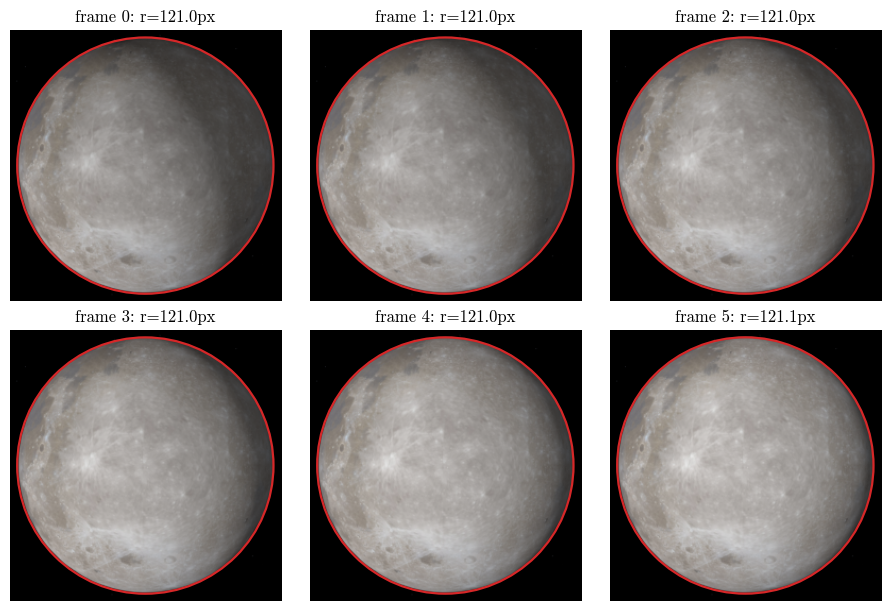

In [5]:
from collections import deque


def largest_component(mask):
    visited = np.zeros_like(mask, dtype=bool)
    best = []
    h, w = mask.shape
    for y0, x0 in zip(*np.nonzero(mask & ~visited)):
        stack = [(int(y0), int(x0))]
        visited[y0, x0] = True
        comp = []
        while stack:
            y, x = stack.pop()
            comp.append((y, x))
            for yn, xn in ((y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)):
                if 0 <= yn < h and 0 <= xn < w and mask[yn, xn] and not visited[yn, xn]:
                    visited[yn, xn] = True
                    stack.append((yn, xn))
        if len(comp) > len(best):
            best = comp
    out = np.zeros_like(mask, dtype=bool)
    if best:
        yy, xx = np.array(best).T
        out[yy, xx] = True
    return out


def fill_holes(mask):
    h, w = mask.shape
    outside = np.zeros_like(mask, dtype=bool)
    q = deque()
    border = []
    border.extend((0, x) for x in range(w))
    border.extend((h - 1, x) for x in range(w))
    border.extend((y, 0) for y in range(h))
    border.extend((y, w - 1) for y in range(h))
    for y, x in border:
        if not mask[y, x] and not outside[y, x]:
            outside[y, x] = True
            q.append((y, x))
    while q:
        y, x = q.popleft()
        for yn, xn in ((y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)):
            if 0 <= yn < h and 0 <= xn < w and not mask[yn, xn] and not outside[yn, xn]:
                outside[yn, xn] = True
                q.append((yn, xn))
    return mask | (~mask & ~outside)


def detect_limb_circle(img):
    gray = img[..., :3].mean(axis=2)
    border = np.concatenate(
        [
            gray[:4, :].ravel(),
            gray[-4:, :].ravel(),
            gray[:, :4].ravel(),
            gray[:, -4:].ravel(),
        ]
    )
    sky = np.median(border)
    mad = np.median(np.abs(border - sky))
    threshold = max(0.010, 8.0 * 1.4826 * mad)

    # NASA-textured, phase-lit renders contain both bright terrain and a dark night-side limb.
    # Segment the Moon as the largest connected object that is different from the border sky,
    # then fill any interior mare/crater holes before fitting the exterior silhouette.
    foreground = np.abs(gray - sky) > threshold
    disk = fill_holes(largest_component(foreground))

    inner = disk.copy()
    for shift in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        inner &= np.roll(disk, shift, axis=(0, 1))
    edge = disk & ~inner
    edge[[0, -1], :] = False
    edge[:, [0, -1]] = False

    y, x = np.nonzero(edge)
    if len(x) < 25:
        raise RuntimeError("Not enough limb pixels for a circle fit")

    a = np.column_stack((2.0 * x, 2.0 * y, np.ones_like(x)))
    b = x**2 + y**2
    xc, yc, c = np.linalg.lstsq(a, b, rcond=None)[0]
    # The binary boundary lies approximately half a pixel inside the continuous limb.
    radius = np.sqrt(max(c + xc**2 + yc**2, 0.0)) + 0.5
    return {
        "xc": xc,
        "yc": yc,
        "radius_px": radius,
        "threshold": threshold,
        "sky": sky,
        "edge_xy": (x, y),
    }


detections = [detect_limb_circle(img) for img in images]

fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)
for ax, img, det, k in zip(axes.ravel(), images[:6], detections[:6], range(6)):
    ax.imshow(img, origin="upper")
    ax.add_patch(
        Circle(
            (det["xc"], det["yc"]),
            det["radius_px"],
            fill=False,
            lw=1.6,
            color="tab:red",
        )
    )
    ax.set_title(f"frame {k}: r={det['radius_px']:.1f}px")
    ax.set_axis_off()
plt.show()

## 4. Convert limb geometry to position measurements

For a spherical Moon, the apparent angular radius is

$$
\alpha = \tan^{-1}\left(\frac{r_{px}}{f_{px}}\right), \qquad
\rho = \frac{R_M}{\sin \alpha},
$$

where $\rho$ is the spacecraft-Moon-center range. The fitted disk center gives the camera-frame bearing to the Moon center. With known camera attitude, each image becomes a direct Moon-centered inertial position measurement of the spacecraft.


In [6]:
def detection_to_position_ci(det, q_cam_to_ci, cam):
    alpha = np.arctan(det["radius_px"] / cam["f_px"])
    rho = R_MOON / np.sin(alpha)
    u_cam = np.array(
        [
            (det["xc"] - cam["cx"]) / cam["f_px"],
            -(det["yc"] - cam["cy"]) / cam["f_px"],
            1.0,
        ]
    )
    u_cam /= np.linalg.norm(u_cam)
    u_ci = q_cam_to_ci @ u_cam
    return -rho * u_ci


z_pos = np.array(
    [
        detection_to_position_ci(det, q.T, cam)
        for det, q in zip(detections, att_ci_to_cam)
    ]
)
raw_pos_err_m = np.linalg.norm(z_pos - truth[:, :3], axis=1)
raw_rad_err_px = np.array(
    [
        det["radius_px"]
        - cam["f_px"] * np.tan(np.arcsin(R_MOON / np.linalg.norm(rv[:3])))
        for det, rv in zip(detections, truth)
    ]
)

print(f"Raw optical position RMS: {np.sqrt(np.mean(raw_pos_err_m**2)) / 1e3:.2f} km")
print(f"Limb radius error RMS   : {np.sqrt(np.mean(raw_rad_err_px**2)):.3f} px")

Raw optical position RMS: 31.87 km
Limb radius error RMS   : 1.054 px


## 5. EKF orbit estimator

The filter state is Cartesian Moon-centered inertial position and velocity,

$$
\mathbf x = [\mathbf r, \mathbf v].
$$

Propagation uses two-body lunar dynamics; the image-derived measurement is position only. The velocity estimate is recovered by the dynamic model tying together the sequence of optical position fixes.


In [7]:
def two_body_accel(r):
    rn = np.linalg.norm(r)
    return -GM_MOON * r / rn**3


def dynamics(x):
    return np.hstack((x[3:], two_body_accel(x[:3])))


def rk4_step(x, dt):
    k1 = dynamics(x)
    k2 = dynamics(x + 0.5 * dt * k1)
    k3 = dynamics(x + 0.5 * dt * k2)
    k4 = dynamics(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def dynamics_jacobian(x):
    r = x[:3]
    rn = np.linalg.norm(r)
    eye = np.eye(3)
    dadr = GM_MOON * (3.0 * np.outer(r, r) / rn**5 - eye / rn**3)
    f = np.zeros((6, 6))
    f[:3, 3:] = eye
    f[3:, :3] = dadr
    return f


def propagate_state_cov(x, p, dt, sigma_accel=2.0e-7):
    n_step = max(1, int(np.ceil(abs(dt) / 60.0)))
    h = dt / n_step
    eye6 = np.eye(6)
    eye3 = np.eye(3)
    for _ in range(n_step):
        f = dynamics_jacobian(x)
        phi = eye6 + f * h
        g = np.vstack((0.5 * h**2 * eye3, h * eye3))
        q = (sigma_accel**2) * (g @ g.T)
        x = rk4_step(x, h)
        p = phi @ p @ phi.T + q
    return x, p


def ekf_update_position(x, p, z, sigma_pos=8.0e3):
    h = np.zeros((3, 6))
    h[:, :3] = np.eye(3)
    r = (sigma_pos**2) * np.eye(3)
    y = z - h @ x
    s = h @ p @ h.T + r
    k = np.linalg.solve(s, h @ p).T
    x = x + k @ y
    i_kh = np.eye(6) - k @ h
    p = i_kh @ p @ i_kh.T + k @ r @ k.T
    return x, p, y


# Start deliberately imperfect: position from the first image plus a rough velocity prior.
x = np.hstack(
    (z_pos[0] + rng.normal(0.0, 15.0e3, 3), truth[0, 3:] + rng.normal(0.0, 8.0, 3))
)
p = np.diag([25.0e3, 25.0e3, 25.0e3, 20.0, 20.0, 20.0]) ** 2

est = []
postfit = []
last_t = times_s[0]
for t, z in zip(times_s, z_pos):
    x, p = propagate_state_cov(x, p, t - last_t)
    x, p, innov = ekf_update_position(x, p, z)
    est.append(x.copy())
    postfit.append(innov)
    last_t = t

est = np.array(est)
postfit = np.array(postfit)
pos_err = np.linalg.norm(est[:, :3] - truth[:, :3], axis=1)
vel_err = np.linalg.norm(est[:, 3:] - truth[:, 3:], axis=1)

print(f"Final position error: {pos_err[-1] / 1e3:.2f} km")
print(f"Final velocity error: {vel_err[-1]:.3f} m/s")
print(f"Filtered position RMS: {np.sqrt(np.mean(pos_err**2)) / 1e3:.2f} km")

Final position error: 47.54 km
Final velocity error: 16.016 m/s
Filtered position RMS: 39.39 km


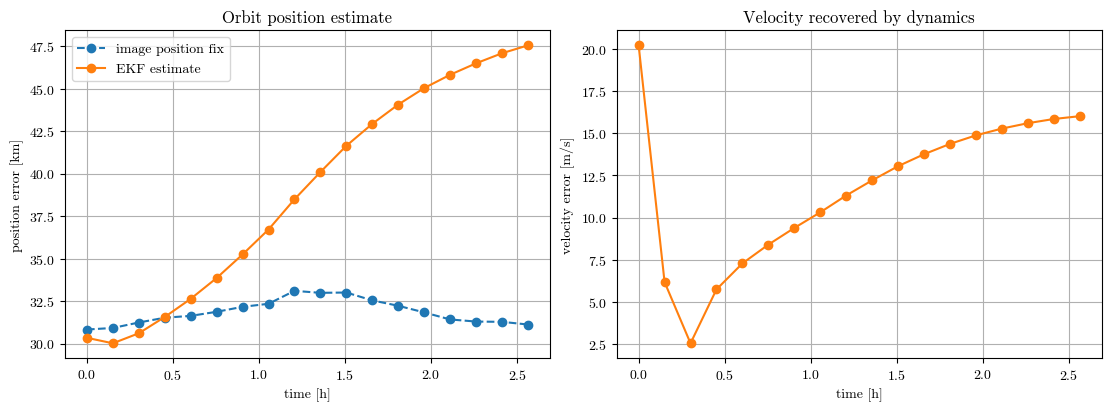

[doc-asset] plots/ex14_opnav.html  (1209 kB)  ->  https://stanford-navlab.github.io/lupnt-doc-assets/plots/ex14_opnav.html


In [8]:
t_hr = (times_s - times_s[0]) / 3600.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(t_hr, raw_pos_err_m / 1e3, "o--", label="image position fix")
axes[0].plot(t_hr, pos_err / 1e3, "o-", label="EKF estimate")
axes[0].set_xlabel("time [h]")
axes[0].set_ylabel("position error [km]")
axes[0].legend()
axes[0].set_title("Orbit position estimate")

axes[1].plot(t_hr, vel_err, "o-", color="tab:orange")
axes[1].set_xlabel("time [h]")
axes[1].set_ylabel("velocity error [m/s]")
axes[1].set_title("Velocity recovered by dynamics")
plt.show()

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON, size_factor=6, alpha=0.45)
pnt.plot.plot_orbits(fig, truth[:, :3], color="royalblue")
fig.data[-1].update(name="truth", showlegend=True)
pnt.plot.plot_orbits(fig, est[:, :3], color="crimson")
fig.data[-1].update(
    name="EKF", showlegend=True, line=dict(color="crimson", width=3, dash="dash")
)
fig.add_scatter3d(
    x=z_pos[:, 0] / 1e6,
    y=z_pos[:, 1] / 1e6,
    z=z_pos[:, 2] / 1e6,
    mode="markers",
    marker=dict(size=3, color="black", opacity=0.72),
    name="image fixes",
)
pnt.plot.set_view(fig, azimuth=-35, elevation=14, zoom=3.0)
fig.update_layout(
    title="Moon-centered inertial orbit",
    width=660,
    height=660,
    margin=dict(l=10, r=10, t=45, b=10),
    legend=dict(x=0.02, y=0.98),
)
embed_plotly(fig, "ex14_opnav")

## Next extensions

This notebook is the tutorial-sized version of an optical-navigation pipeline. Natural extensions are to use a non-spherical lunar shape model, fit only illuminated limb pixels, estimate camera attitude or alignment biases, add lens distortion calibration, or replace the EKF with a batch smoother over many images.